In [86]:
import pandas as pd
import numpy as np
import MetaTrader5 as mt5
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from datetime import datetime
import pytz

plt.style.use('fivethirtyeight') 
sns.set_style("darkgrid")

In [ ]:
if not mt5.initialize():
    print("Failed to initialize MetaTrader5. Error = ",mt5.last_error())
    mt5.shutdown()

### Getting the data from MetaTrader5

In [88]:
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_H1

# set time zone to UTC
timezone = pytz.timezone("Etc/UTC")

# create 'datetime' objects in UTC time zone to avoid the implementation of a local time zone offset
utc_from = datetime(2023, 1, 1, tzinfo=timezone)
utc_to = datetime(2025, 6, 24, hour = 0, tzinfo=timezone)

rates = mt5.copy_rates_range(symbol, timeframe, utc_from, utc_to)

if rates is None:
    print(f"Failed to copy rates for symbol={symbol}. MT5 Error = {mt5.last_error()}")

In [89]:
rates_df = pd.DataFrame(rates) # we convert rates object to a dataframe
rates_df["time"] = pd.to_datetime(rates_df["time"], unit="s") # we convert the time from seconds to datatime

rates_df

,time,open,high,low,close,tick_volume,spread,real_volume
0,2023-01-02 00:00:00,1.06908,1.07002,1.06850,1.06898,750,100,0
1,2023-01-02 01:00:00,1.06980,1.07056,1.06946,1.07056,5709,2,0
2,2023-01-02 02:00:00,1.07057,1.07089,1.06938,1.07071,2266,2,0
3,2023-01-02 03:00:00,1.07071,1.07092,1.06899,1.06984,223,2,0
4,2023-01-02 04:00:00,1.06983,1.06983,1.06898,1.06952,1007,2,0
...,...,...,...,...,...,...,...,...
15404,2025-06-23 20:00:00,1.15448,1.15735,1.15406,1.15693,4616,0,0
15405,2025-06-23 21:00:00,1.15693,1.15780,1.15661,1.15743,3442,0,0
15406,2025-06-23 22:00:00,1.15742,1.15789,1.15704,1.15785,2175,0,0
15407,2025-06-23 23:00:00,1.15785,1.15817,1.15748,1.15783,1221,0,0


### PROPHET model

In [90]:
prophet_df = pd.DataFrame({
    "time": rates_df["time"],
    "volatility": rates_df["high"] - rates_df["low"]
}).set_index("time")

prophet_df

,volatility
time,
2023-01-02 00:00:00,0.00152
2023-01-02 01:00:00,0.00110
2023-01-02 02:00:00,0.00151
2023-01-02 03:00:00,0.00193
2023-01-02 04:00:00,0.00085
...,...
2025-06-23 20:00:00,0.00329
2025-06-23 21:00:00,0.00119
2025-06-23 22:00:00,0.00085


<Axes: title={'center': 'Volatility (high-low) against time'}, xlabel='time', ylabel='volatility'>

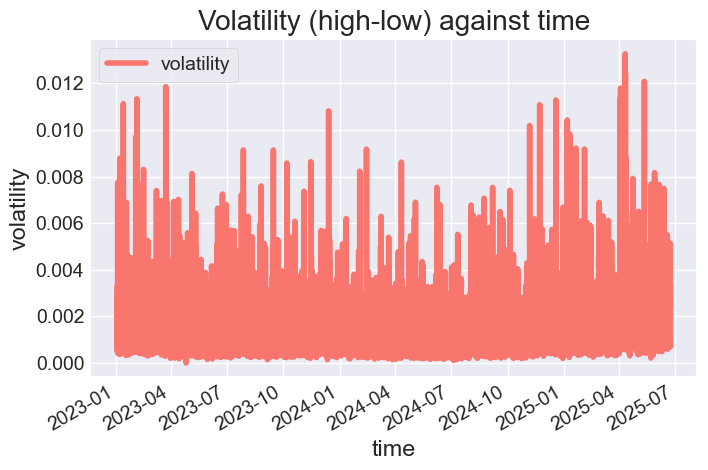

In [91]:
# Color pallete for plotting
color_pal = ["#F8766D", "#D39200", "#93AA00",
             "#00BA38", "#00C19F", "#00B9E3",
             "#619CFF", "#DB72FB"]

prophet_df.plot(figsize=(7,5), color=color_pal, title="Volatility (high-low) against time", ylabel="volatility", xlabel="time")

In [92]:
def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekofyear']]
    if label:
        y = df[label]
        return X, y
    return X


X, y = create_features(prophet_df, label='volatility')

features_and_target = pd.concat([X, y], axis=1)

In [93]:
features_and_target.head()

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,volatility
time,,,,,,,,,
2023-01-02 00:00:00,0,0,1,1,2023,2,2,1,0.00152
2023-01-02 01:00:00,1,0,1,1,2023,2,2,1,0.00110
2023-01-02 02:00:00,2,0,1,1,2023,2,2,1,0.00151
2023-01-02 03:00:00,3,0,1,1,2023,2,2,1,0.00193
2023-01-02 04:00:00,4,0,1,1,2023,2,2,1,0.00085


### Plotting the features to see the trends

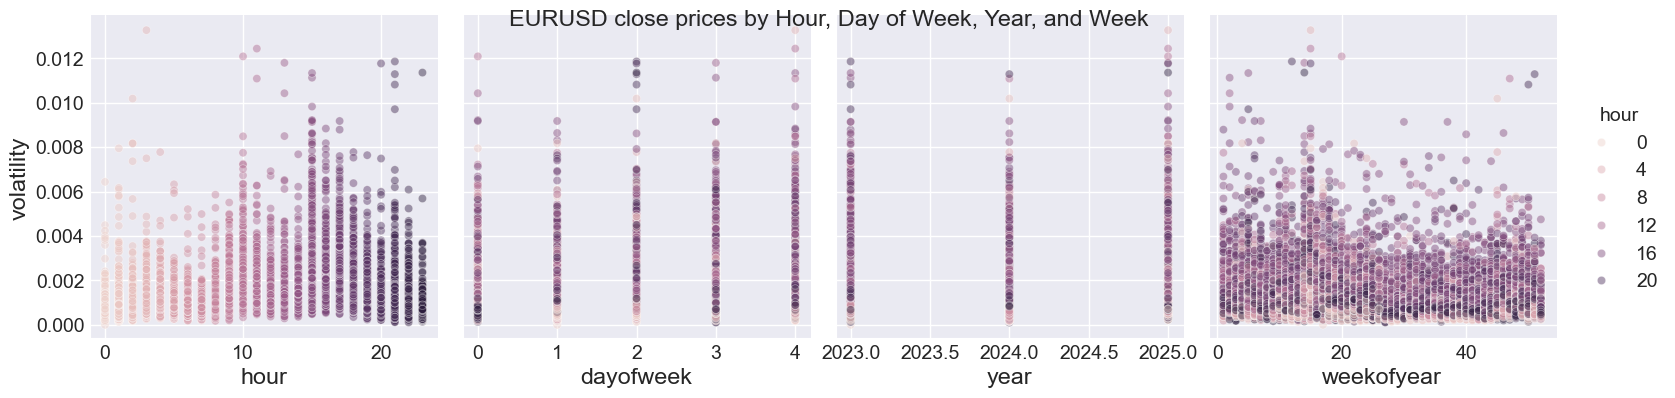

In [94]:
sns.pairplot(features_and_target.dropna(),
             hue='hour',
             x_vars=['hour','dayofweek',
                     'year','weekofyear'],
             y_vars='volatility',
             height=4,
             plot_kws={'alpha':0.45, 'linewidth':0.5}
            )

plt.suptitle(f"{symbol} close prices by Hour, Day of Week, Year, and Week")
plt.show()

### Train-Test Split

In [95]:
prophet_df

,volatility
time,
2023-01-02 00:00:00,0.00152
2023-01-02 01:00:00,0.00110
2023-01-02 02:00:00,0.00151
2023-01-02 03:00:00,0.00193
2023-01-02 04:00:00,0.00085
...,...
2025-06-23 20:00:00,0.00329
2025-06-23 21:00:00,0.00119
2025-06-23 22:00:00,0.00085


In [96]:
split_date = '01-Jan-2025'

prophet_df_train = prophet_df.loc[prophet_df.index <= split_date].copy().reset_index().rename(columns={"time": "ds", "volatility": "y"})
prophet_df_test = prophet_df.loc[prophet_df.index > split_date].copy().reset_index().rename(columns={"time": "ds", "volatility": "y"})

In [97]:
prophet_df_train

,ds,y
0,2023-01-02 00:00:00,0.00152
1,2023-01-02 01:00:00,0.00110
2,2023-01-02 02:00:00,0.00151
3,2023-01-02 03:00:00,0.00193
4,2023-01-02 04:00:00,0.00085
...,...,...
12451,2024-12-31 19:00:00,0.00109
12452,2024-12-31 20:00:00,0.00114
12453,2024-12-31 21:00:00,0.00131
12454,2024-12-31 22:00:00,0.00087


In [98]:
# %%time
model = Prophet()

model.fit(prophet_df_train)

10:50:23 - cmdstanpy - INFO - Chain [1] start processing
10:50:33 - cmdstanpy - INFO - Chain [1] done processing


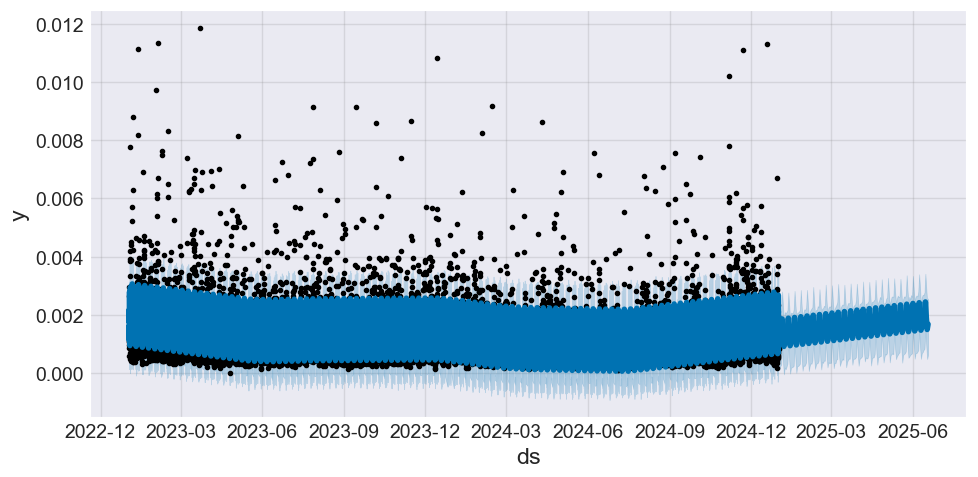

In [99]:
# Create future dataframe for predictions
future = model.make_future_dataframe(periods=168)

# Make predictions
forecast = model.predict(future)

# Plot the results
fig = model.plot(forecast, figsize=(10, 5))

In [100]:
# Predict on training set with model
test_fcst = model.predict(df=prophet_df_test)

In [101]:
test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-02 00:00:00,0.001670,-0.000062,0.001826,0.001670,0.001670,-0.000759,-0.000759,-0.000759,-0.000648,-0.000648,-0.000648,-0.000110,-0.000110,-0.000110,0.0,0.0,0.0,0.000912
1,2025-01-02 01:00:00,0.001670,-0.000028,0.001839,0.001670,0.001670,-0.000787,-0.000787,-0.000787,-0.000683,-0.000683,-0.000683,-0.000104,-0.000104,-0.000104,0.0,0.0,0.0,0.000883
2,2025-01-02 02:00:00,0.001671,0.000245,0.002055,0.001671,0.001671,-0.000601,-0.000601,-0.000601,-0.000504,-0.000504,-0.000504,-0.000097,-0.000097,-0.000097,0.0,0.0,0.0,0.001069
3,2025-01-02 03:00:00,0.001671,0.000374,0.002342,0.001671,0.001671,-0.000376,-0.000376,-0.000376,-0.000285,-0.000285,-0.000285,-0.000091,-0.000091,-0.000091,0.0,0.0,0.0,0.001294
4,2025-01-02 04:00:00,0.001671,0.000420,0.002314,0.001671,0.001671,-0.000345,-0.000345,-0.000345,-0.000260,-0.000260,-0.000260,-0.000085,-0.000085,-0.000085,0.0,0.0,0.0,0.001326


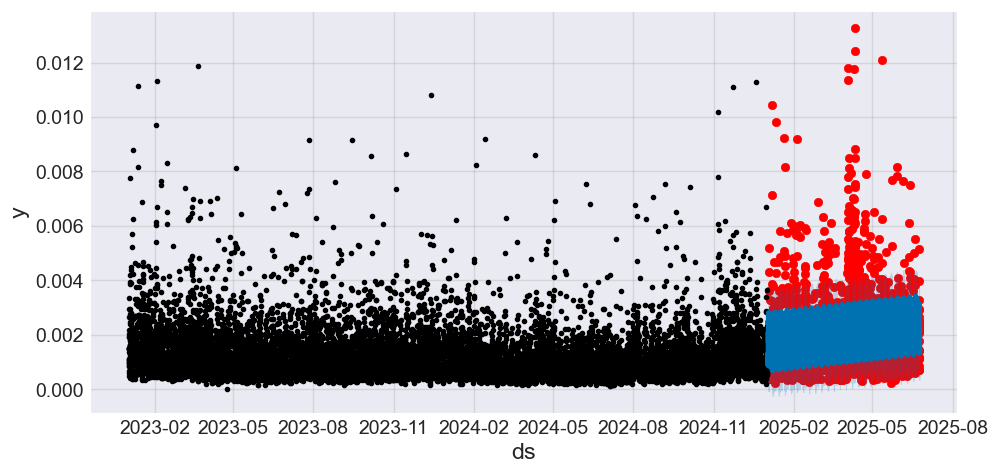

In [102]:
# Plot the forecast with the actuals

f, ax = plt.subplots(figsize=(10,5))
ax.scatter(prophet_df_test["ds"], prophet_df_test['y'], color='r')

fig = model.plot(test_fcst, ax=ax)

### Evaluate One Month

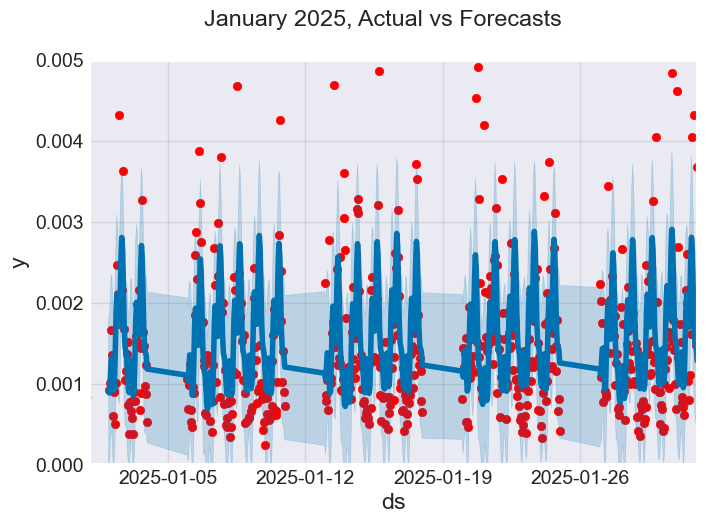

In [103]:
f, ax = plt.subplots(figsize=(7, 5))

ax.scatter(prophet_df_test["ds"], prophet_df_test['y'], color='r')
fig = model.plot(test_fcst, ax=ax)
ax.set_xbound(
            lower=pd.to_datetime("2025-01-01"), # starting data on the x axis
            upper=pd.to_datetime("2025-02-01")) # ending data on the x axis

ax.set_ylim(0, 0.005)
plot = plt.suptitle("January 2025, Actual vs Forecasts")

### Evaluate a single day forecasts

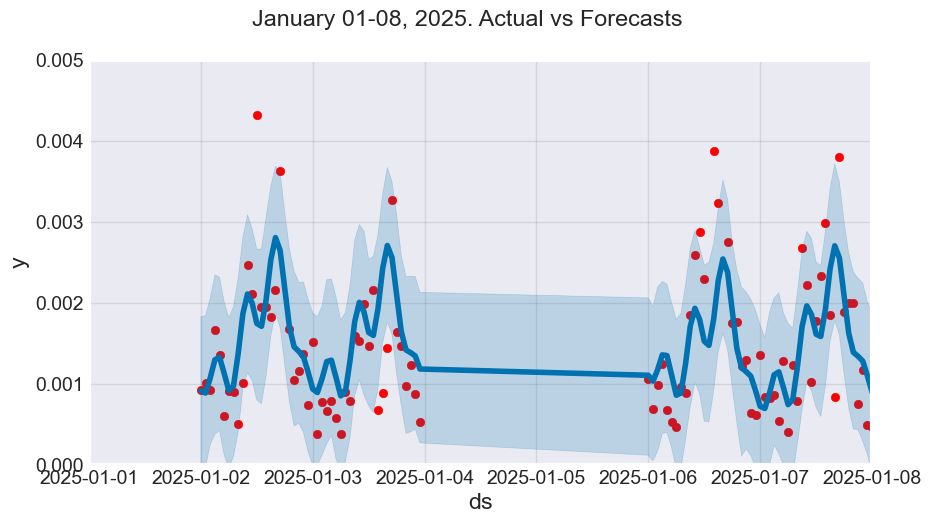

In [104]:
f, ax = plt.subplots(figsize=(9, 5))

ax.scatter(prophet_df_test["ds"], prophet_df_test['y'], color='r')
fig = model.plot(test_fcst, ax=ax)
ax.set_xbound(
            lower=pd.to_datetime("2025-01-01"),
            upper=pd.to_datetime("2025-01-08"))

ax.set_ylim(0, 0.005)
plot = plt.suptitle("January 01-08, 2025. Actual vs Forecasts")

In [105]:
test_pred = test_fcst.yhat

test_pred

0       0.000912
1       0.000883
2       0.001069
3       0.001294
4       0.001326
          ...   
2948    0.001802
2949    0.001755
2950    0.001698
2951    0.001522
2952    0.001327
Name: yhat, Length: 2953, dtype: float64

In [106]:
prophet_df_test["y"]

0       0.00092
1       0.00101
2       0.00092
3       0.00166
4       0.00135
         ...   
2948    0.00329
2949    0.00119
2950    0.00085
2951    0.00069
2952    0.00071
Name: y, Length: 2953, dtype: float64

In [107]:
import sklearn.metrics as metric

def forecast_accuracy(forecast, actual):
    # Convert to numpy arrays if they aren't already
    forecast = np.asarray(forecast)
    actual = np.asarray(actual)
    
    metrics = {
        'mape': metric.mean_absolute_percentage_error(actual, forecast),
        'me': np.mean(forecast - actual),  # Mean Error
        'mae': metric.mean_absolute_error(actual, forecast),
        'mpe': np.mean((forecast - actual) / actual),  # Mean Percentage Error
        'rmse': metric.root_mean_squared_error(actual, forecast),
        'minmax': 1 - np.mean(np.minimum(forecast, actual) / np.maximum(forecast, actual)),
        "r2_score": metric.r2_score(forecast, actual)
    }
    return metrics


results = forecast_accuracy(test_pred, prophet_df_test["y"])

for metric_name, value in results.items():
    print(f"{metric_name:<10}: {value:.6f}")

mape      : 0.525882
me        : 0.000012
mae       : 0.000780
mpe       : 0.323308
rmse      : 0.001211
minmax    : 0.320563
r2_score  : -3.610552


### Adding holidays to the Model

In [108]:
from Trade.TerminalInfo import CTerminalInfo
import os

terminal = CTerminalInfo()
data_path = os.path.join(terminal.common_data_path(), "Files")

In [109]:
timeframe = "PERIOD_H1"
df = pd.read_csv(os.path.join(data_path, f"{symbol}.{timeframe}.OHLC + News.csv"))

df

,Time,Open,High,Low,Close,Name,Sector,Importance,Actual,Forecast,Previous
0,2023.01.02 01:00:00,1.06967,1.06983,1.06927,1.06983,New Year's Day,CALENDAR_SECTOR_HOLIDAYS,CALENDAR_IMPORTANCE_NONE,0.0,0.0,0.0
1,2023.01.02 02:00:00,1.06984,1.07059,1.06914,1.07041,New Year's Day,CALENDAR_SECTOR_HOLIDAYS,CALENDAR_IMPORTANCE_NONE,0.0,0.0,0.0
2,2023.01.02 03:00:00,1.07059,1.07069,1.06858,1.06910,New Year's Day,CALENDAR_SECTOR_HOLIDAYS,CALENDAR_IMPORTANCE_NONE,0.0,0.0,0.0
3,2023.01.02 04:00:00,1.06909,1.06909,1.06828,1.06880,New Year's Day,CALENDAR_SECTOR_HOLIDAYS,CALENDAR_IMPORTANCE_NONE,0.0,0.0,0.0
4,2023.01.02 05:00:00,1.06881,1.07029,1.06880,1.06897,New Year's Day,CALENDAR_SECTOR_HOLIDAYS,CALENDAR_IMPORTANCE_NONE,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
15369,2025.06.20 18:00:00,1.15136,1.15289,1.15112,1.15196,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.0,0.0,0.0
15370,2025.06.20 19:00:00,1.15196,1.15374,1.15191,1.15362,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.0,0.0,0.0
15371,2025.06.20 20:00:00,1.15362,1.15442,1.15318,1.15323,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.0,0.0,0.0
15372,2025.06.20 21:00:00,1.15323,1.15371,1.15271,1.15287,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.0,0.0,0.0


In [110]:
np.unique(df["Name"])

array(['(null)', '10-Year BTP Auction', '10-Year Bond Auction',
       '10-Year Note Auction', '10-Year OAT Auction',
       '10-Year Obligacion Auction', '10-Year TIPS Auction',
       '12-Month BOT Auction', '12-Month BTF Auction',
       '12-Month Letras Auction', '15-Year Obligacion Auction',
       '2-Year CTZ Auction', '2-Year Note Auction',
       '20-Year Bond Auction', '3-Month Bill Auction',
       '3-Year BTP Auction', '3-Year Bonos Auction',
       '3-Year Note Auction', '3-Year OAT Auction', '30-Year BTP Auction',
       '30-Year Bond Auction', '30-Year Obligacion Auction',
       '30-Year TIPS Auction', '5-Year Bonos Auction',
       '5-Year Note Auction', '5-Year OAT Auction', '5-Year TIPS Auction',
       '50-Year Obligacion Auction', '52-Week Bill Auction',
       '6-Month BOT Auction', '6-Month BTF Auction',
       '6-Month Bill Auction', '7-Year BTP Auction',
       '7-Year Note Auction', '8-Week Bill Auction',
       '9-Month Letras Auction', 'ADP Nonfarm Employment

In [125]:
news_df = df[
    (df['Name'] != "(null)") & # Filter rows without news at all
    ((df['Importance'] == "CALENDAR_IMPORTANCE_HIGH") | (df['Importance'] == "CALENDAR_IMPORTANCE_MODERATE")) # Filter other news except high importance news
].copy()

news_df

,Time,Open,High,Low,Close,Name,Sector,Importance,Actual,Forecast,Previous
7,2023.01.02 08:00:00,1.06921,1.06973,1.06724,1.06858,S&P Global Manufacturing PMI,CALENDAR_SECTOR_BUSINESS,CALENDAR_IMPORTANCE_MODERATE,47.10,47.400,47.400
8,2023.01.02 09:00:00,1.06878,1.06909,1.06627,1.06784,S&P Global Manufacturing PMI,CALENDAR_SECTOR_BUSINESS,CALENDAR_IMPORTANCE_MODERATE,47.80,47.800,47.800
31,2023.01.03 08:00:00,1.06636,1.06677,1.06514,1.06524,Unemployment,CALENDAR_SECTOR_JOBS,CALENDAR_IMPORTANCE_MODERATE,2.52,2.522,2.538
37,2023.01.03 14:00:00,1.05283,1.05490,1.05241,1.05355,S&P Global Manufacturing PMI,CALENDAR_SECTOR_BUSINESS,CALENDAR_IMPORTANCE_HIGH,46.20,46.200,46.200
38,2023.01.03 15:00:00,1.05353,1.05698,1.05304,1.05602,Construction Spending m/m,CALENDAR_SECTOR_HOUSING,CALENDAR_IMPORTANCE_MODERATE,0.20,0.200,-0.300
...,...,...,...,...,...,...,...,...,...,...,...
15369,2025.06.20 18:00:00,1.15136,1.15289,1.15112,1.15196,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.00,0.000,0.000
15370,2025.06.20 19:00:00,1.15196,1.15374,1.15191,1.15362,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.00,0.000,0.000
15371,2025.06.20 20:00:00,1.15362,1.15442,1.15318,1.15323,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.00,0.000,0.000
15372,2025.06.20 21:00:00,1.15323,1.15371,1.15271,1.15287,Eurogroup Meeting,CALENDAR_SECTOR_GOVERNMENT,CALENDAR_IMPORTANCE_MODERATE,0.00,0.000,0.000


In [178]:
holidays = news_df[['Time', 'Name']].rename(columns={
    'Time': 'ds',
    'Name': 'holiday'
})

holidays['ds'] = pd.to_datetime(holidays['ds'])  # Ensure datetime format

holidays['lower_window'] = 0
holidays['upper_window'] = 1 

holidays

,ds,holiday,lower_window,upper_window
7,2023-01-02 08:00:00,S&P Global Manufacturing PMI,0,1
8,2023-01-02 09:00:00,S&P Global Manufacturing PMI,0,1
31,2023-01-03 08:00:00,Unemployment,0,1
37,2023-01-03 14:00:00,S&P Global Manufacturing PMI,0,1
38,2023-01-03 15:00:00,Construction Spending m/m,0,1
...,...,...,...,...
15369,2025-06-20 18:00:00,Eurogroup Meeting,0,1
15370,2025-06-20 19:00:00,Eurogroup Meeting,0,1
15371,2025-06-20 20:00:00,Eurogroup Meeting,0,1
15372,2025-06-20 21:00:00,Eurogroup Meeting,0,1


In [179]:
model_w_holidays = Prophet(holidays=holidays)
model_w_holidays.fit(prophet_df_train)

11:51:59 - cmdstanpy - INFO - Chain [1] start processing
11:52:39 - cmdstanpy - INFO - Chain [1] done processing


In [180]:
# Predict on training set with model
test_fcst = model_w_holidays.predict(df=prophet_df_test)

test_pred = test_fcst.yhat

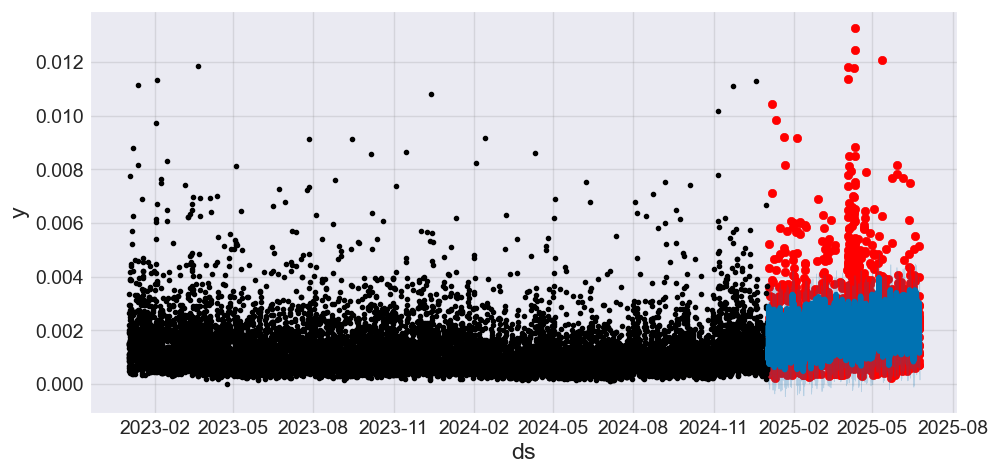

In [181]:
# Plot the forecast with the actuals

f, ax = plt.subplots(figsize=(10,5))
ax.scatter(prophet_df_test["ds"], prophet_df_test['y'], color='r')

fig = model_w_holidays.plot(test_fcst, ax=ax)

In [182]:
results = forecast_accuracy(test_pred, prophet_df_test["y"])

for metric_name, value in results.items():
    print(f"{metric_name:<10}: {value:.6f}")

mape      : 0.506827
me        : -0.000053
mae       : 0.000783
mpe       : 0.271597
rmse      : 0.001234
minmax    : 0.320422
r2_score  : -3.318859
